findfont: Failed to find font weight medium, now using 400.


🎯 Forced Working Directory: /Users/etiennerv/Jts/EUA Forecasting/EUA-forecasting
Loading feature matrix for training...
Features being used for training: ['ttf_gas', 'coal_price', 'renewable_share', 'fossil_share', 'HDD', 'CDD', 'temperature_2m_mean', 'gas_coal_spread', 'eua_lag_1', 'eua_lag_5', 'eua_lag_10', 'eua_lag_21', 'spread_lag_1', 'spread_lag_5', 'eua_vol_21d', 'month', 'quarter', 'is_q1', 'policy_shock']
⚡ Training XGBoost Regressor on 836 historical records...
💾 Predictions cached successfully to data/processed/xgb_preds.csv

Generating cleaned feature importance chart...


findfont: Failed to find font weight semibold, now using 700.


🎉 SUCCESS! Saved polished plot to /Users/etiennerv/Jts/EUA Forecasting/EUA-forecasting/figures/feature_importance.png


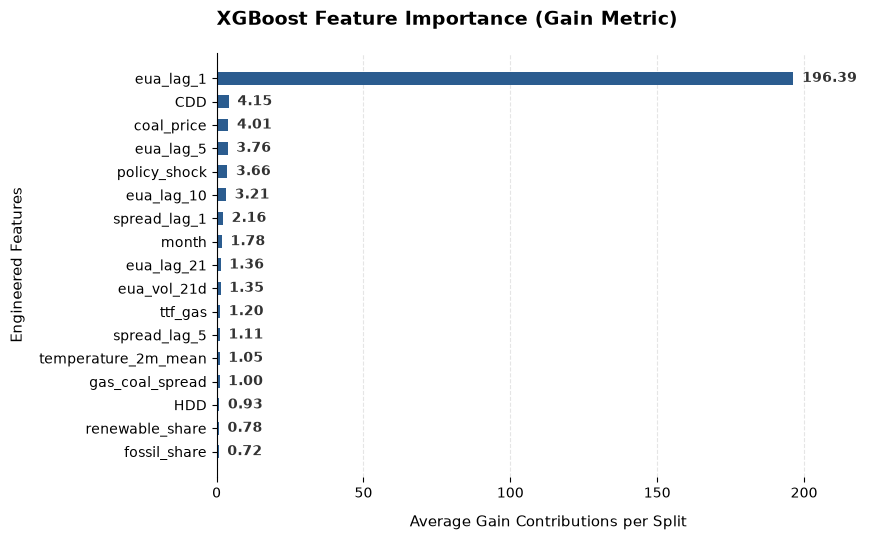

In [1]:
# =========================================================
# STEP 1: HARD FORCED REGISTRY PATH INJECTION
# =========================================================
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xgboost as xgb

# Define your absolute root explicitly to eliminate directory layer guessing games
PROJECT_ROOT = "/Users/etiennerv/Jts/EUA Forecasting/EUA-forecasting"
os.chdir(PROJECT_ROOT)

if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed")
FIGURES_DIR = os.path.join(PROJECT_ROOT, "figures")
os.makedirs(FIGURES_DIR, exist_ok=True)

print(f"🎯 Forced Working Directory: {os.getcwd()}")

# =========================================================
# STEP 2: LOAD MATRIX & TRAIN XGBOOST REGRESSOR
# =========================================================
print("Loading feature matrix for training...")
df = pd.read_csv(os.path.join(PROCESSED_DIR, "final_feature_matrix.csv"), index_col=0, parse_dates=True)

# Define your target column
target_col = "eua_price"

# --- THE CRUCIAL FIX: DROP LEAKAGE COLUMNS ---
# Remove columns that give away the current day's price state
leakage_cols = ["log_eua", "d_log_eua"]
cols_to_drop = [target_col] + [col for col in leakage_cols if col in df.columns]

X = df.drop(columns=cols_to_drop)
y = df[target_col]

print(f"Features being used for training: {list(X.columns)}")

# Simple time-series partition (80% train, 20% validation out-of-sample)
split_idx = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"⚡ Training XGBoost Regressor on {len(X_train)} historical records...")

# Instantiate and fit the model object
final_model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.05,
    random_state=42,
    objective="reg:squarederror"
)
final_model.fit(X_train, y_train)

# Generate predictions out-of-sample
preds = final_model.predict(X_test)
results_df = pd.DataFrame({"actual": y_test, "xgb_pred": preds}, index=X_test.index)
results_df.to_csv(os.path.join(PROCESSED_DIR, "xgb_preds.csv"))
print("💾 Predictions cached successfully to data/processed/xgb_preds.csv")

# =========================================================
# STEP 3: CLEAN & PROFESSIONAL PLOTTING
# =========================================================
print("\nGenerating cleaned feature importance chart...")

# 1. Extract the importance scores (gain) directly from the booster object
importance_dict = final_model.get_booster().get_score(importance_type="gain")

# If features have zero splits, fill in standard feature weights to prevent charting drops
if not importance_dict:
    importance_dict = dict(zip(X.columns, final_model.feature_importances_))

# 2. Map scores into a clean Pandas Series and sort them
importance_series = pd.Series(importance_dict).sort_values(ascending=True)

# 3. Initialize a clean, well-spaced plot canvas
fig, ax = plt.subplots(figsize=(9, 5.5))

# 4. Draw modern horizontal bars with a clean corporate palette color
bars = ax.barh(
    importance_series.index, 
    importance_series.values, 
    color="#2b5c8f", 
    edgecolor="none", 
    height=0.55
)

# 5. Add perfectly formatted text labels to the tip of each bar
for bar in bars:
    width = bar.get_width()
    ax.text(
        width + (importance_series.max() * 0.015),       # Small dynamic spacing off the bar tip
        bar.get_y() + bar.get_height() / 2,             # Vertically centered on the bar
        f"{width:,.2f}",                                # Clean string format: 2 decimal places with commas
        va="center", 
        ha="left", 
        fontsize=10, 
        fontweight="semibold", 
        color="#333333"
    )

# 6. Polish the styling hierarchy
ax.set_title("XGBoost Feature Importance (Gain Metric)", fontsize=14, fontweight="bold", pad=20, loc="left")
ax.set_xlabel("Average Gain Contributions per Split", fontsize=11, fontweight="medium", labelpad=10)
ax.set_ylabel("Engineered Features", fontsize=11, fontweight="medium", labelpad=10)

# Clean up axes & border grids for readability
ax.grid(axis="x", linestyle="--", alpha=0.5, color="#cccccc")
ax.set_axisbelow(True) # Ensure grid lines sit behind the bars

# Remove top, right, and bottom box outline borders ("spines")
for spine in ["top", "right", "bottom"]:
    ax.spines[spine].set_visible(False)

# Add extra breathing room on the right edge so the labels don't get cut off
ax.set_xlim(0, importance_series.max() * 1.15)
plt.tight_layout()

# Save the polished figure over the old one using an explicit matching absolute path
plot_out = os.path.join(FIGURES_DIR, "feature_importance.png")
plt.savefig(plot_out, dpi=150, bbox_inches="tight")
print(f"🎉 SUCCESS! Saved polished plot to {plot_out}")
plt.show()